In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df=pd.read_csv('insurance.csv')

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [6]:
df.sample(5)

,age,sex,bmi,children,smoker,region,charges
37,26,male,20.800,0,no,southwest,2302.30000
807,19,female,36.575,0,no,northwest,2136.88225
229,47,male,25.460,2,no,northeast,9225.25640
653,45,female,36.300,2,no,southeast,8527.53200
528,46,male,39.425,1,no,northeast,8342.90875


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.shape

(1338, 7)

In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.duplicated().sum()

1

In [12]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.shape

(1337, 7)

In [15]:
print(df['sex'].value_counts())    
print(40*'=')

print(df['smoker'].value_counts())
print(40*'=')


print(df['region'].value_counts())  
print(40*'=')
    

print(df['children'].value_counts())
print(40*'=')


sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64
children
0    573
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


Smoking has the strongest impact on medical insurance charges.
Medical charges generally increase with age.
Higher BMI is associated with higher insurance charges.
Gender has little effect on insurance charges.
The number of children has a relatively small effect on insurance charges.
1Region does not significantly affect medical charges.

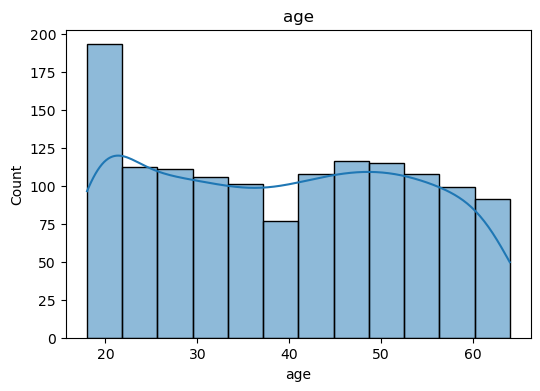

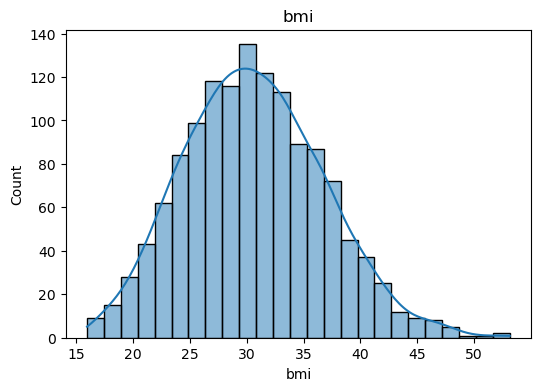

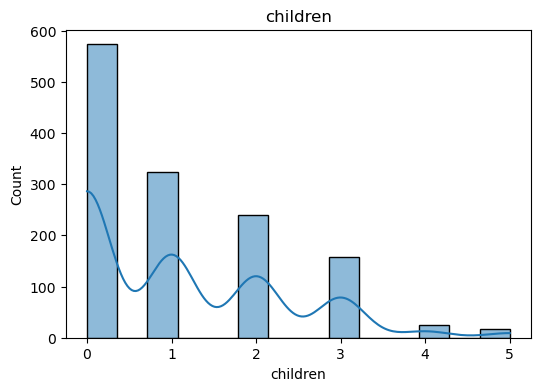

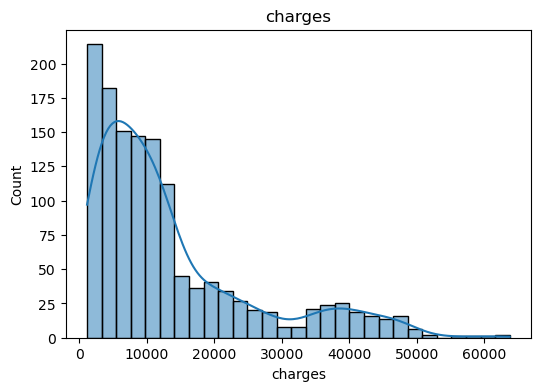

In [16]:
num_cols = ['age', 'bmi', 'children', 'charges']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

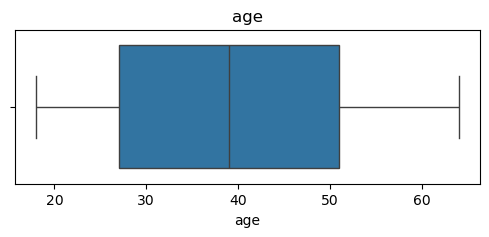

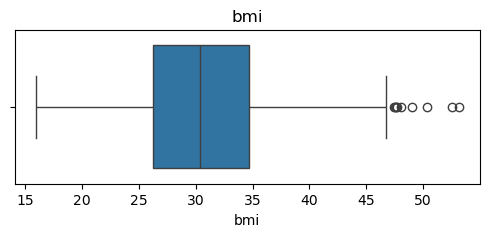

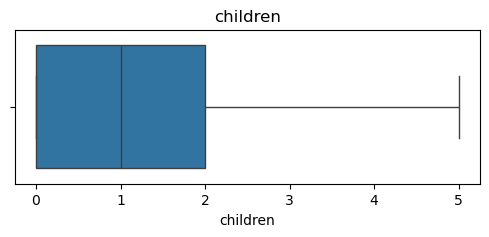

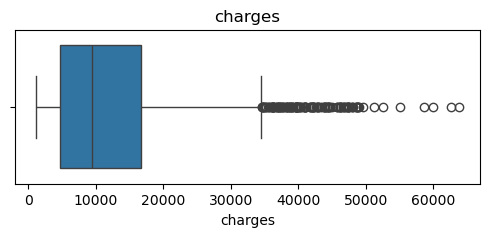

In [17]:
for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

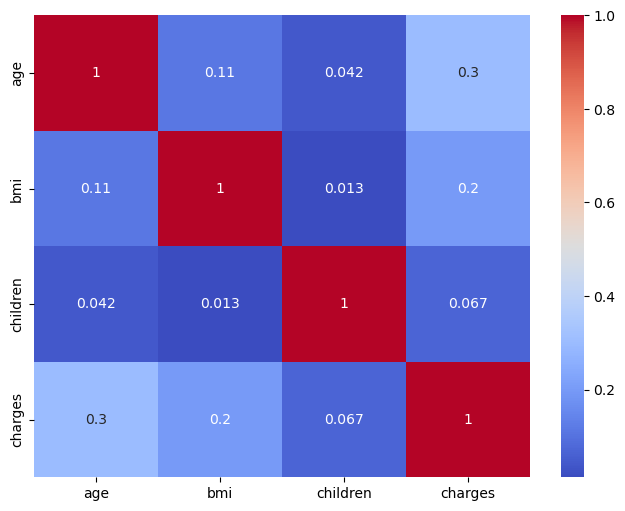

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

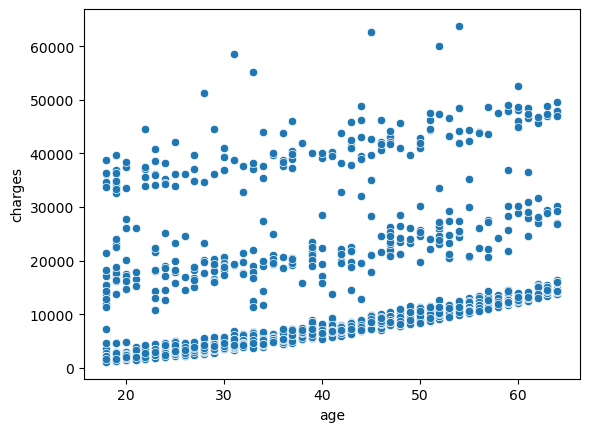

In [19]:
sns.scatterplot(data=df, x='age', y='charges')
plt.show()

In [20]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

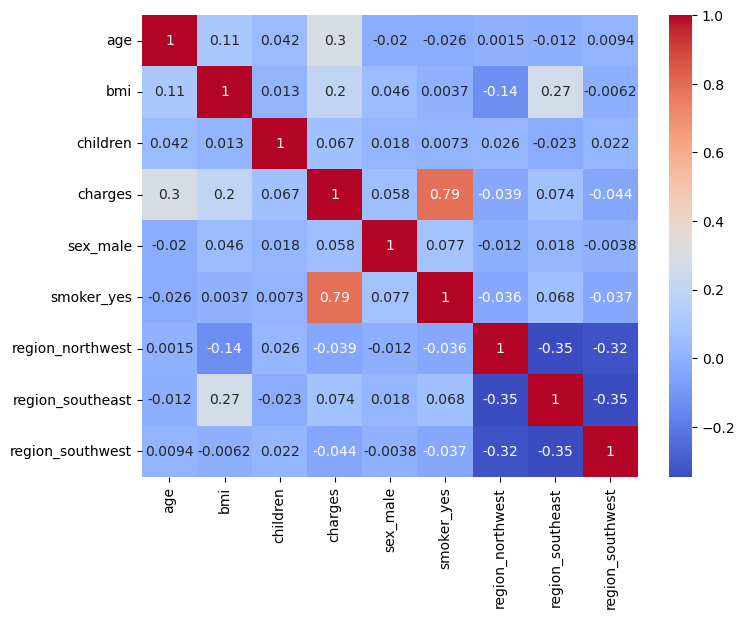

In [21]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [22]:
df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [23]:
X=df.drop('charges', axis=1)
y=df['charges']

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score, mean_absolute_error


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()


In [25]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 :", r2_score(y_test, y_pred))

MAE : 4177.045561036319
MSE : 35478020.67523559
RMSE: 5956.342894363587
R2 : 0.8069287081198012


In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients.sort_values(by='Coefficient', ascending=False))

            Feature   Coefficient
4        smoker_yes  23077.764593
2          children    533.009989
1               bmi    318.701441
0               age    248.210720
3          sex_male   -101.542054
5  region_northwest   -391.761455
7  region_southwest   -659.139752
6  region_southeast   -838.919616


In [28]:
import joblib

joblib.dump(model, "insurance_model.pkl")
joblib.dump(X.columns.tolist(), "columns.pkl")

['columns.pkl']

In [ ]:
import joblib
import pandas as pd

# Load model
model = joblib.load("insurance_model.pkl")
columns = joblib.load("columns.pkl")

# User input
age = int(input("Enter Age: "))
bmi = float(input("Enter BMI: "))
children = int(input("Enter Number of Children: "))

sex = input("Enter Sex (male/female): ").lower()
smoker = input("Smoker? (yes/no): ").lower()
region = input("Region (northeast/northwest/southeast/southwest): ").lower()

# Create input
data = {
    "age": age,
    "bmi": bmi,
    "children": children,
    "sex_male": sex == "male",
    "smoker_yes": smoker == "yes",
    "region_northwest": region == "northwest",
    "region_southeast": region == "southeast",
    "region_southwest": region == "southwest",
}

input_df = pd.DataFrame([data])
input_df = input_df[columns]

# Prediction
prediction = model.predict(input_df)

print(f"\nPredicted Insurance Charge: ${prediction[0]:,.2f}")